<a href="https://colab.research.google.com/github/KinzaAslam/ClothingAnalytics/blob/main/PA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Let's first organize the dataset as per the image and later use Prophet for prediction.
import pandas as pd
from io import StringIO

# Reading data into a DataFrame
df = pd.read_excel('Predictive_Analysis.xlsx')

# Outputting the cleaned data for verification
df.head()


,Date,ID,Type,Customer Preferences,Price,Likes,Dislikes,Brand
0,2022-01-01,1,Coat,"Warm, Waterproof",120,Warmth,Bulky,Brand A
1,2022-02-01,2,Jacket,"Warm, Waterproof",85,Style,Not warm enough,Brand A
2,2022-03-01,3,Sweater,"Warm, Waterproof",60,Softness,Pills easily,Brand A
3,2022-04-01,4,Scarf,"Warm, Waterproof",25,Warm,Itchy,Brand A
4,2022-05-01,5,Gloves,"Warm, Waterproof",30,Touchscreen,Tight fit,Brand A


In [ ]:
pip install prophet


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np

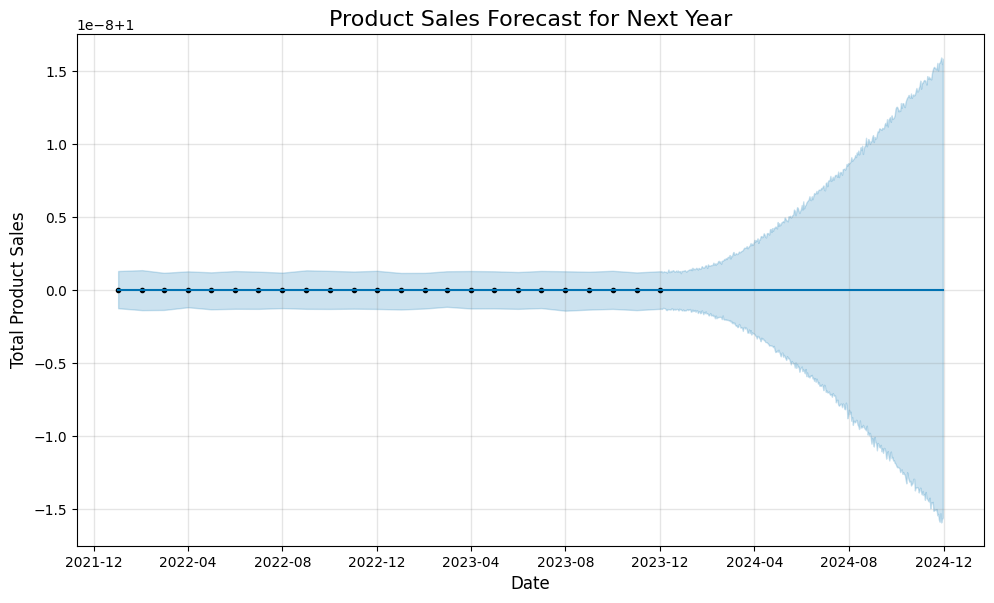

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the dataset (Simulating the loaded data here based on provided structure)
data = {
    'Date': ['1/1/2022', '2/1/2022', '3/1/2022', '4/1/2022', '5/1/2022', '6/1/2022', '7/1/2022', '8/1/2022',
             '9/1/2022', '10/1/2022', '11/1/2022', '12/1/2022', '1/1/2023', '2/1/2023', '3/1/2023', '4/1/2023',
             '5/1/2023', '6/1/2023', '7/1/2023', '8/1/2023', '9/1/2023', '10/1/2023', '11/1/2023', '12/1/2023'],
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Type': ['Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves',
             'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater'],
    'Price': [120, 85, 60, 25, 30, 20, 150, 130, 95, 75, 18, 40, 22, 140, 180, 110, 55, 28, 32, 15, 155, 125, 105, 50],
    'Brand': ['Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand B', 'Brand B',
              'Brand B', 'Brand B', 'Brand B', 'Brand B', 'Brand B', 'Brand C', 'Brand C', 'Brand C', 'Brand C',
              'Brand C', 'Brand C', 'Brand C', 'Brand D', 'Brand D', 'Brand D']
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Grouping by Date to count total occurrences of all product types over time
product_trend = df.groupby('Date').size().reset_index(name='Total')

# Preparing the data for Prophet
df_prophet = product_trend.rename(columns={'Date': 'ds', 'Total': 'y'})

# Initialize and fit the Prophet model
model = Prophet()
model.fit(df_prophet)

# Create a future dataframe (1 year into the future)
future = model.make_future_dataframe(periods=365)

# Make predictions
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title("Product Sales Forecast for Next Year", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Product Sales", fontsize=12)
plt.grid(True)
plt.show()


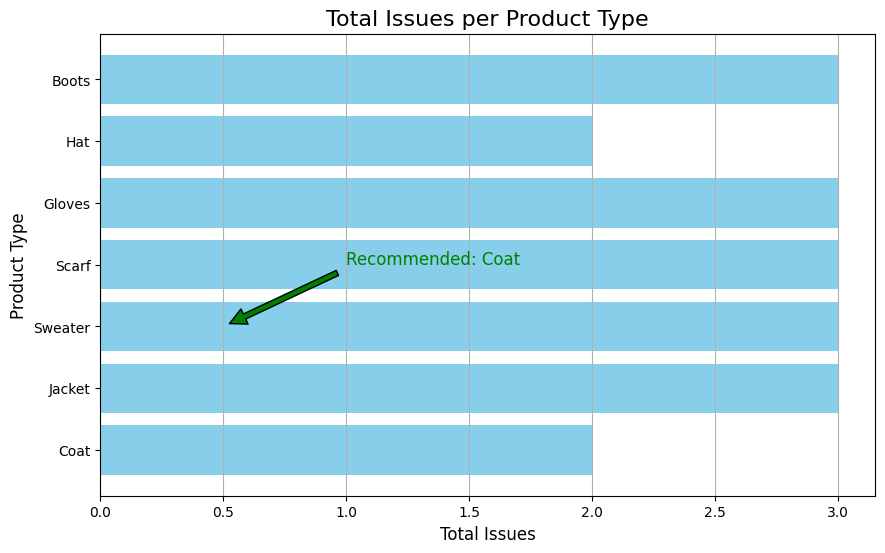

In [ ]:

import matplotlib.pyplot as plt

# Summarizing issues faced by each product type
issue_summary = {
    'Coat': ['Not warm enough', 'Not stylish'],
    'Jacket': ['Not breathable', 'Expensive', 'Not warm enough'],
    'Sweater': ['Pills easily', 'Shrinks after wash', 'Expensive'],
    'Scarf': ['Itchy', 'Not warm enough', 'Fades after wash'],
    'Gloves': ['Not waterproof', 'Shrinks after wash', 'Not durable'],
    'Hat': ['Itchy', 'Not warm enough'],
    'Boots': ['Heavy', 'Not waterproof', 'Expensive']
}

# Counting total issues per product
issue_count = {product: len(issues) for product, issues in issue_summary.items()}

# Converting issue summary to DataFrame for plotting
issue_df = pd.DataFrame(list(issue_count.items()), columns=['Product', 'Total Issues'])

# Plotting the issues count per product to visualize recommendation
plt.figure(figsize=(10, 6))
plt.barh(issue_df['Product'], issue_df['Total Issues'], color='skyblue')
plt.title('Total Issues per Product Type', fontsize=16)
plt.xlabel('Total Issues', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.grid(axis='x')

# Adding recommendation logic
recommended_product = issue_df.loc[issue_df['Total Issues'].idxmin(), 'Product']
plt.annotate(f'Recommended: {recommended_product}', xy=(0.5, issue_df['Total Issues'].min()),
             xytext=(1, issue_df['Total Issues'].min() + 1),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=12, color='green')

# Display the plot
plt.show()


In [6]:
!pip install prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/w62gylt7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/ekjbw28s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60477', 'data', 'file=/tmp/tmpqxwe2f3p/w62gylt7.json', 'init=/tmp/tmpqxwe2f3p/ekjbw28s.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelobpjj1uz/prophet_model-20241005055724.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:24 - cmdstanpy - INFO - Chain [1] start processing
I

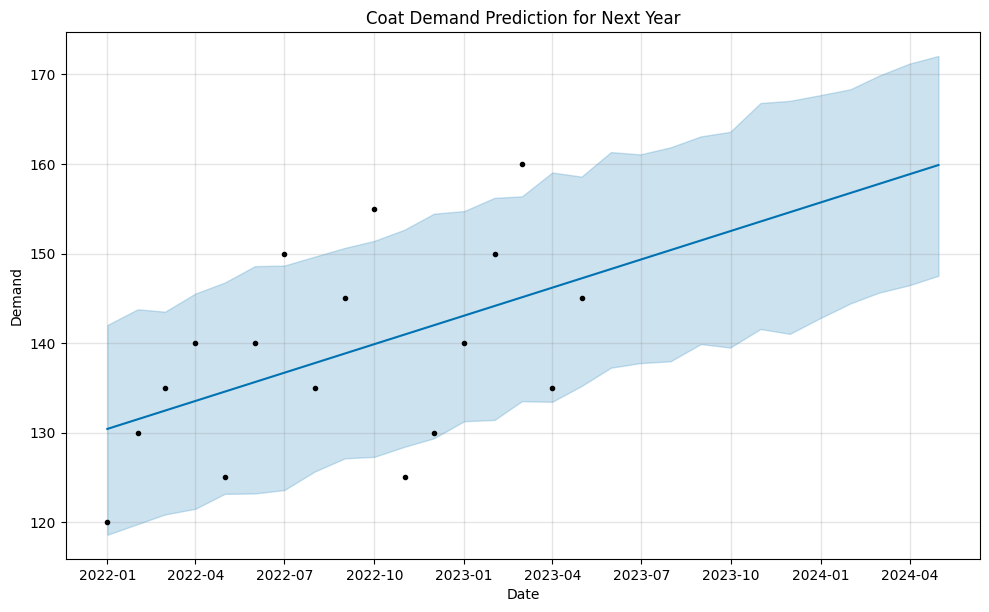

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


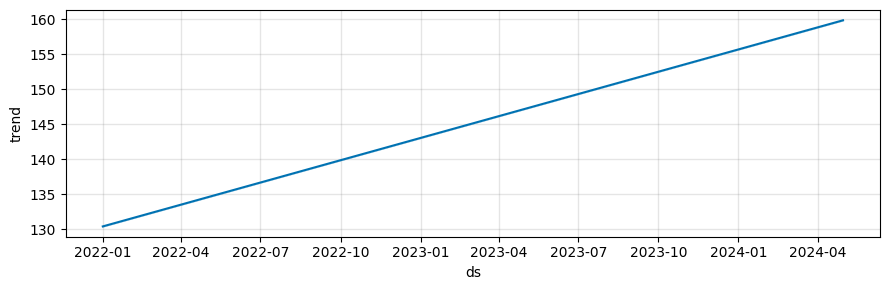

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/ky8vm8p4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/oawgu1ve.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=10606', 'data', 'file=/tmp/tmpqxwe2f3p/ky8vm8p4.json', 'init=/tmp/tmpqxwe2f3p/oawgu1ve.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_model3h4oxv_p/prophet_model-20241005055726.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:26 - cmdstanpy - INFO - Chain [1] start processing
I

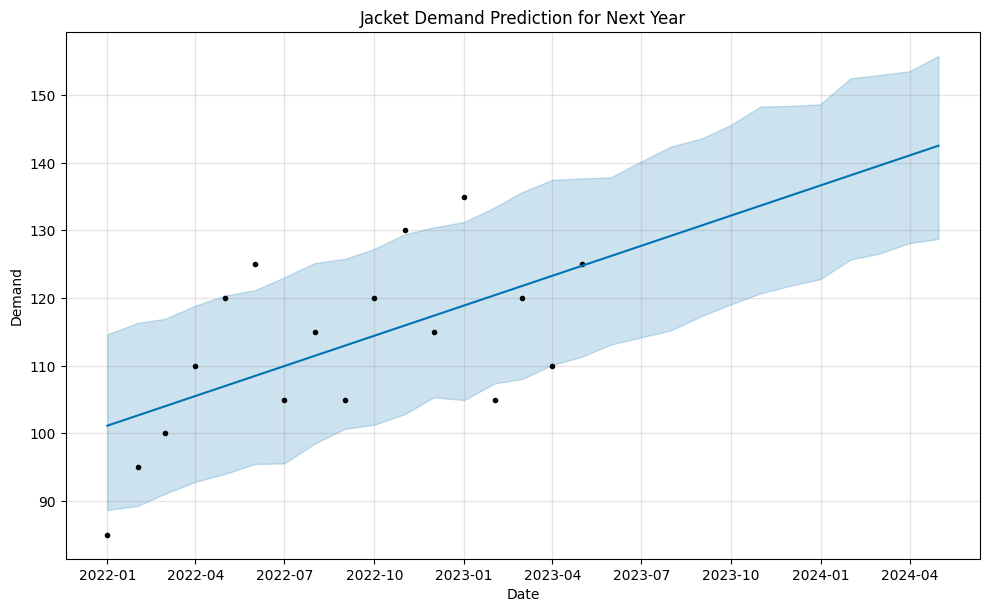

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


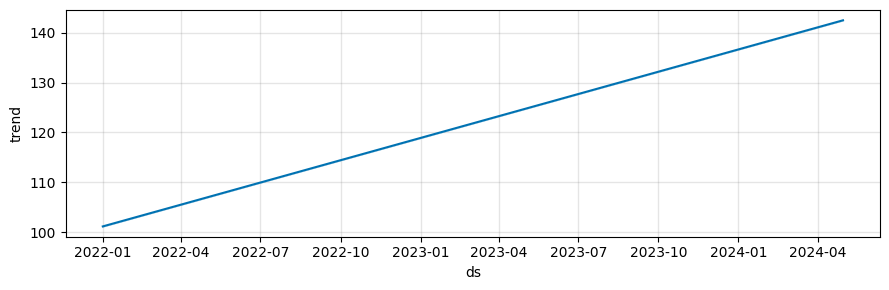

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/_c1c_jh6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/xew7s7ji.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74973', 'data', 'file=/tmp/tmpqxwe2f3p/_c1c_jh6.json', 'init=/tmp/tmpqxwe2f3p/xew7s7ji.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelvgly8_1a/prophet_model-20241005055728.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:28 - cmdstanpy - INFO - Chain [1] start processing
I

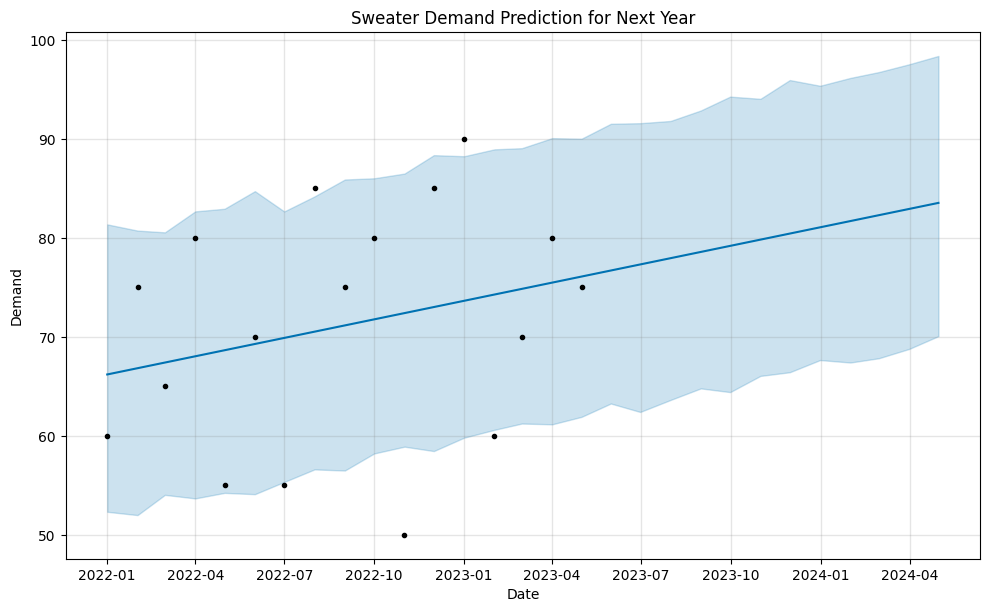

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


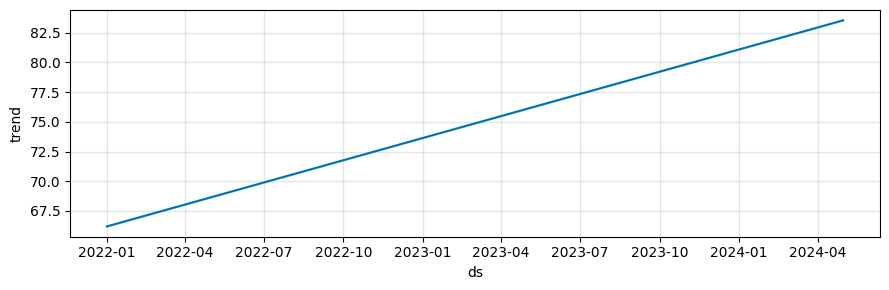

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/g2sa3gat.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/vhtmzktr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=55347', 'data', 'file=/tmp/tmpqxwe2f3p/g2sa3gat.json', 'init=/tmp/tmpqxwe2f3p/vhtmzktr.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modeltkjvf9tr/prophet_model-20241005055729.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:29 - cmdstanpy - INFO - Chain [1] start processing
I

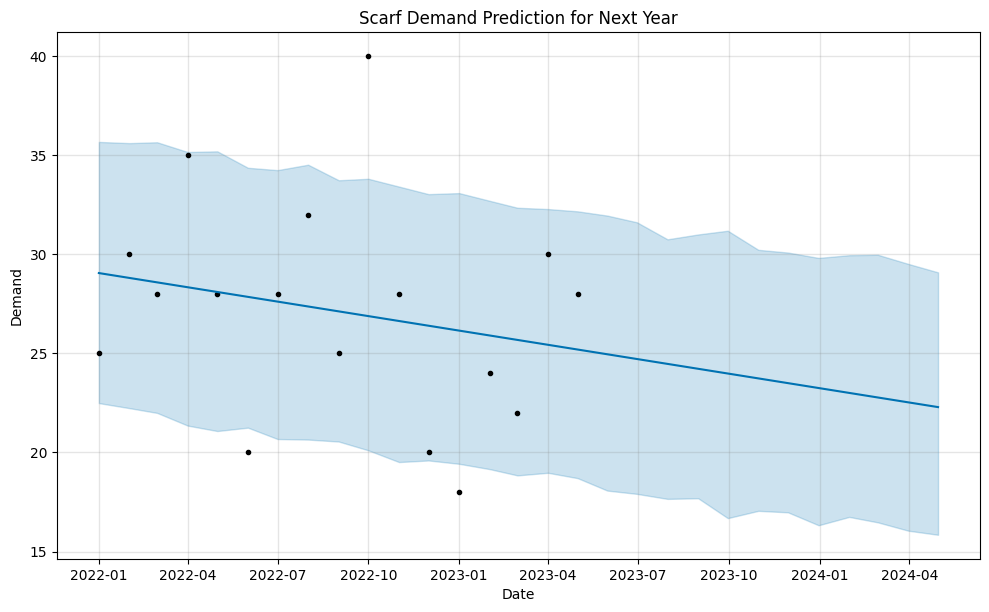

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


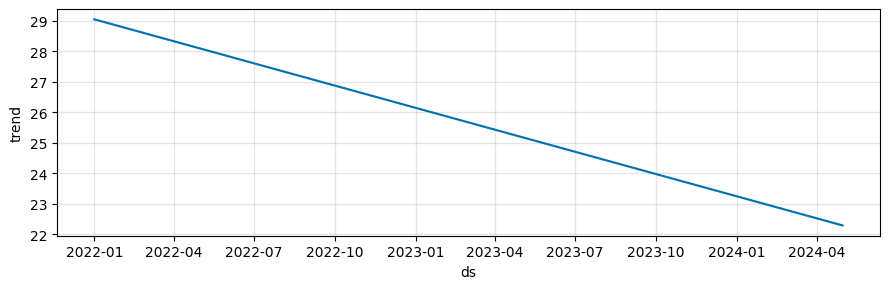

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/6cj1qei0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/1ioxdtkz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47786', 'data', 'file=/tmp/tmpqxwe2f3p/6cj1qei0.json', 'init=/tmp/tmpqxwe2f3p/1ioxdtkz.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_model6ue8v43j/prophet_model-20241005055730.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:30 - cmdstanpy - INFO - Chain [1] start processing
I

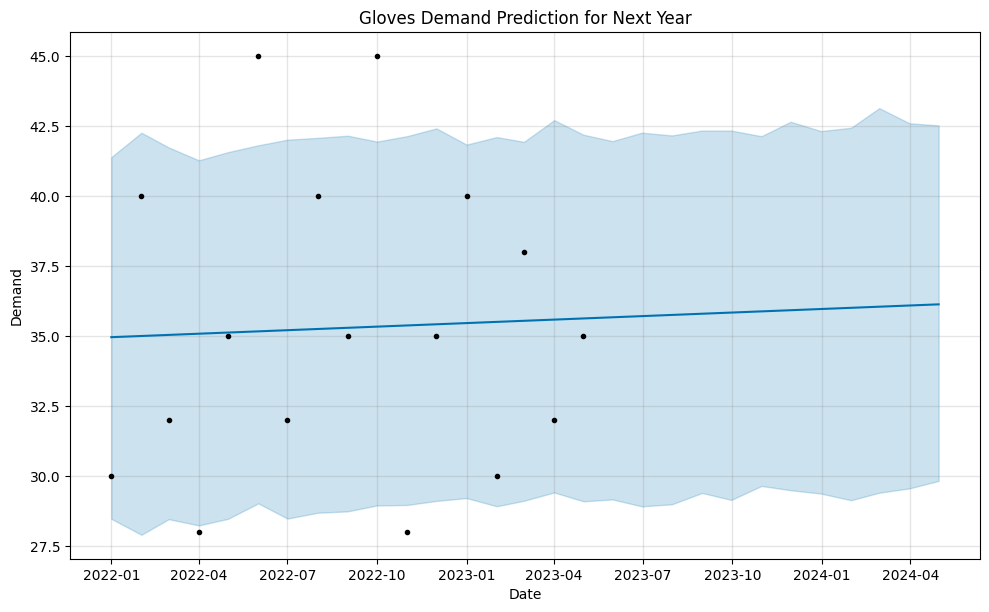

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


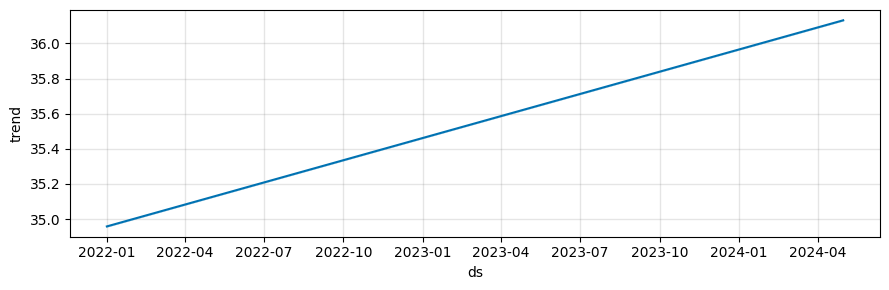

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/eiq2nuqv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/a95yebga.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48182', 'data', 'file=/tmp/tmpqxwe2f3p/eiq2nuqv.json', 'init=/tmp/tmpqxwe2f3p/a95yebga.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelt6trds6t/prophet_model-20241005055731.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:31 - cmdstanpy - INFO - Chain [1] start processing
I

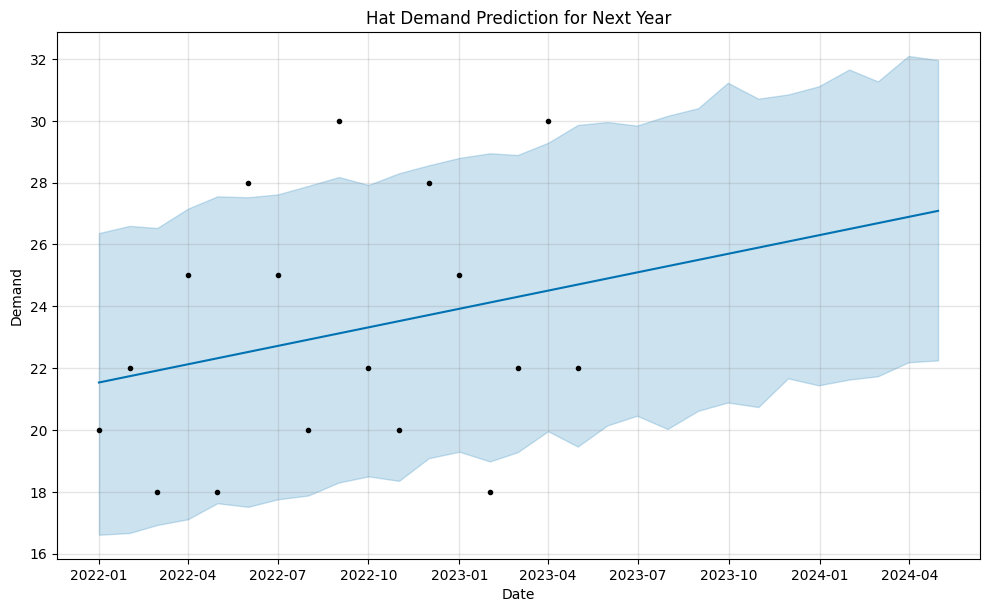

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


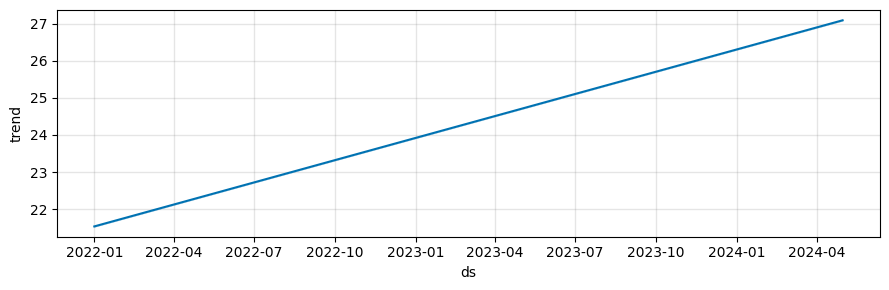

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/e814t851.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/mi45x0xv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=26196', 'data', 'file=/tmp/tmpqxwe2f3p/e814t851.json', 'init=/tmp/tmpqxwe2f3p/mi45x0xv.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_model1hzol37p/prophet_model-20241005055732.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:57:32 - cmdstanpy - INFO - Chain [1] start processing
I

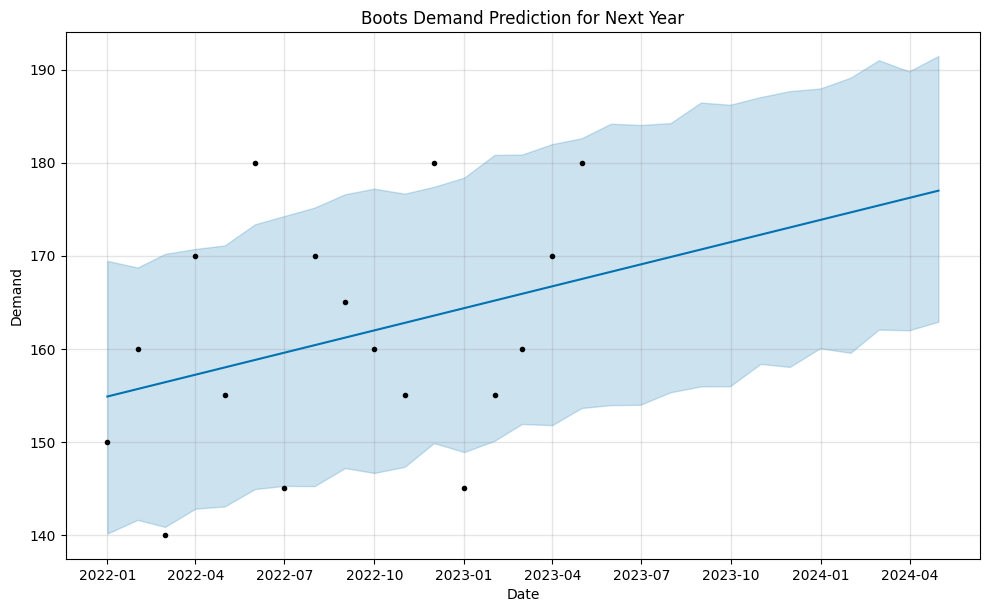

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


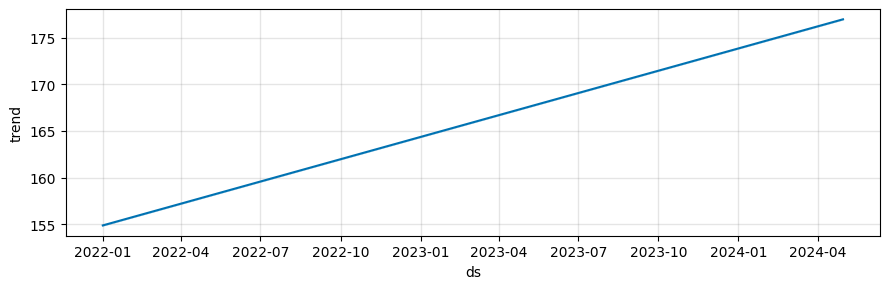

In [9]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Sample data (replace with your actual data)
df = pd.read_excel('Predictive_Analysis.xlsx')

# Convert data to DataFrame
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])

# Function to run Prophet for each product type
def predict_product_demand(df, product):
    df_product = df[['Date', product]].rename(columns={'Date': 'ds', product: 'y'})

    # Initialize and fit the Prophet model
    model = Prophet()
    model.fit(df_product)

    # Create future dates for the next 12 months
    future = model.make_future_dataframe(periods=12, freq='M')

    # Predict future values
    forecast = model.predict(future)

    # Plot the forecast
    fig1 = model.plot(forecast)
    plt.title(f"{product} Demand Prediction for Next Year")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.show()

    # Plot components (Trend, Seasonality, etc.)
    fig2 = model.plot_components(forecast)
    plt.show()

# List of all product types in the dataset
products = ['Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots']

# Loop through all product types and predict future demand
for product in products:
    predict_product_demand(df, product)


In [11]:
import pandas as pd
from prophet import Prophet

# Sample data (replace with actual data provided)
df = pd.read_excel('Predictive_Analysis.xlsx')


# Convert data to DataFrame
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])

# Function to run Prophet for each product and return the forecasted demand
def get_forecast(df, product):
    df_product = df[['Date', product]].rename(columns={'Date': 'ds', product: 'y'})

    # Initialize and fit the Prophet model
    model = Prophet()
    model.fit(df_product)

    # Create future dates for the next 12 months
    future = model.make_future_dataframe(periods=12, freq='M')

    # Predict future values
    forecast = model.predict(future)

    # Return forecast for the next year
    return forecast[['ds', 'yhat']].tail(12)

# List of all product types in the dataset
products = ['Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots']

# Dictionary to store forecasts
forecasts = {}

# Get forecasts for each product
for product in products:
    forecasts[product] = get_forecast(df, product)

# Summarize the results by calculating the total forecasted demand for the next year
total_forecasts = {product: forecasts[product]['yhat'].sum() for product in products}

# Sort the products by total forecasted demand
recommended_product = max(total_forecasts, key=total_forecasts.get)

# Display the recommended product and the demand forecast
recommended_product, total_forecasts[recommended_product]


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/u2nmr_m_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/4scyjat6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59654', 'data', 'file=/tmp/tmpqxwe2f3p/u2nmr_m_.json', 'init=/tmp/tmpqxwe2f3p/4scyjat6.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modeljvtakt9i/prophet_model-20241005055954.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:59:54 - cmdstanpy - INFO - Chain [1] start processing
I

('Boots', 2071.596573158516)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/87l97mc9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/nxe9l_mf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2192', 'data', 'file=/tmp/tmpqxwe2f3p/87l97mc9.json', 'init=/tmp/tmpqxwe2f3p/nxe9l_mf.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelxb5x7rm8/prophet_model-20241005060547.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cm

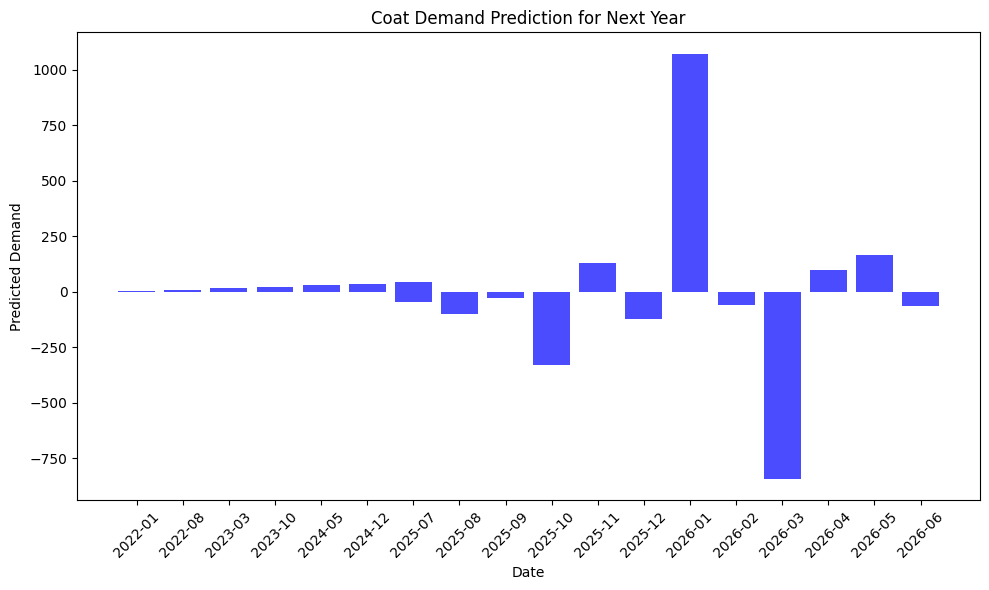

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/j1ppyusx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/0x7tbifb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=70623', 'data', 'file=/tmp/tmpqxwe2f3p/j1ppyusx.json', 'init=/tmp/tmpqxwe2f3p/0x7tbifb.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelz7txjvtz/prophet_model-20241005060551.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

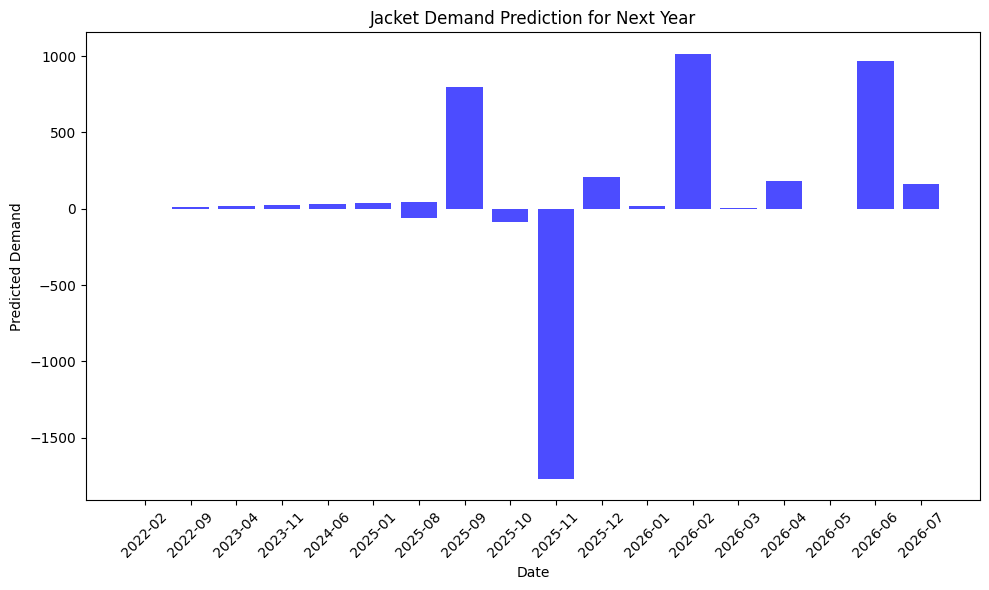

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/j30bdl9c.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/cvh3flby.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61844', 'data', 'file=/tmp/tmpqxwe2f3p/j30bdl9c.json', 'init=/tmp/tmpqxwe2f3p/cvh3flby.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_model0zg8319c/prophet_model-20241005060552.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

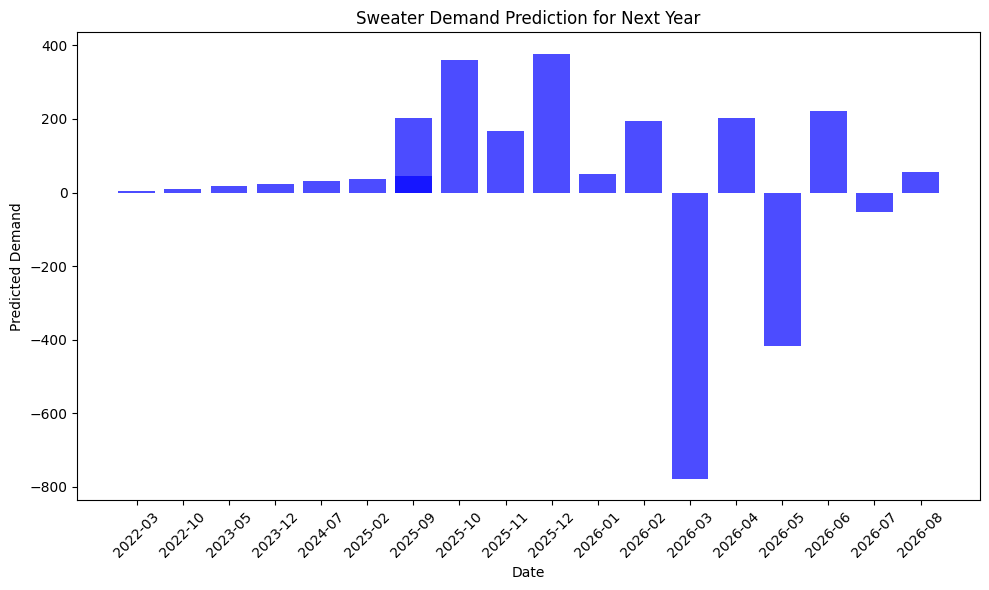

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/6_no9kpd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/cz8ox1ii.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35322', 'data', 'file=/tmp/tmpqxwe2f3p/6_no9kpd.json', 'init=/tmp/tmpqxwe2f3p/cz8ox1ii.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelfpye2pt9/prophet_model-20241005060553.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

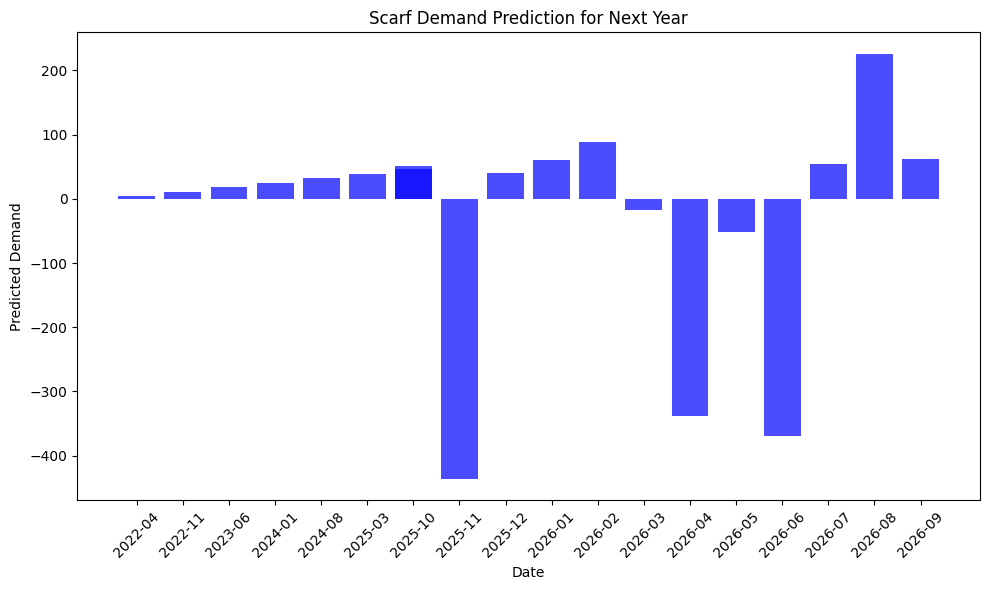

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/bpjpx2l7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/amzc6gy8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53158', 'data', 'file=/tmp/tmpqxwe2f3p/bpjpx2l7.json', 'init=/tmp/tmpqxwe2f3p/amzc6gy8.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_model0g6h72cx/prophet_model-20241005060554.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

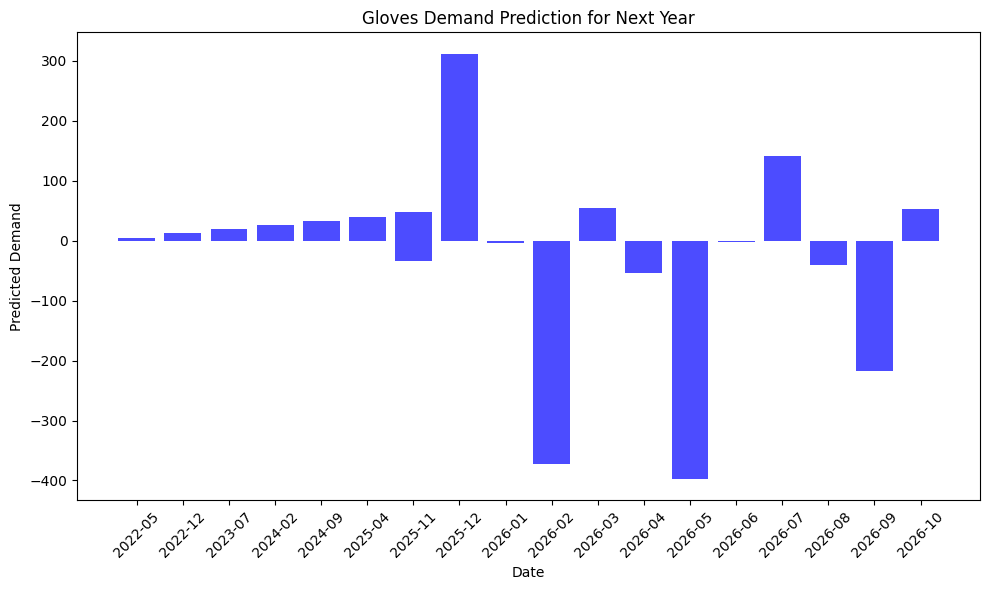

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/p5rhkma9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/4qpu1b4f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54479', 'data', 'file=/tmp/tmpqxwe2f3p/p5rhkma9.json', 'init=/tmp/tmpqxwe2f3p/4qpu1b4f.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelzptkqfrn/prophet_model-20241005060555.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

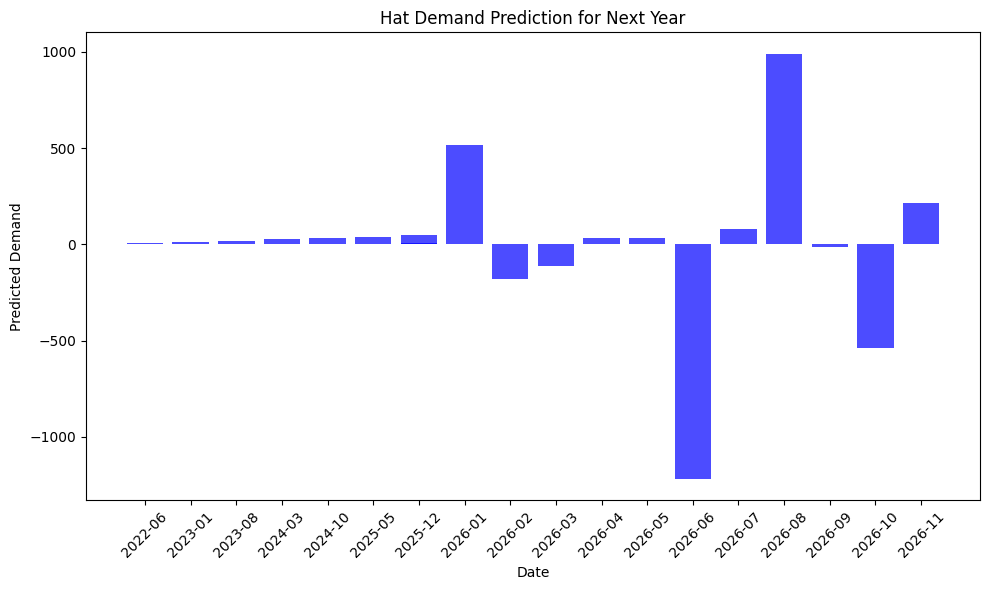

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/y8ojh7f1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqxwe2f3p/1v_nnroz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56816', 'data', 'file=/tmp/tmpqxwe2f3p/y8ojh7f1.json', 'init=/tmp/tmpqxwe2f3p/1v_nnroz.json', 'output', 'file=/tmp/tmpqxwe2f3p/prophet_modelvf7_7tvn/prophet_model-20241005060556.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

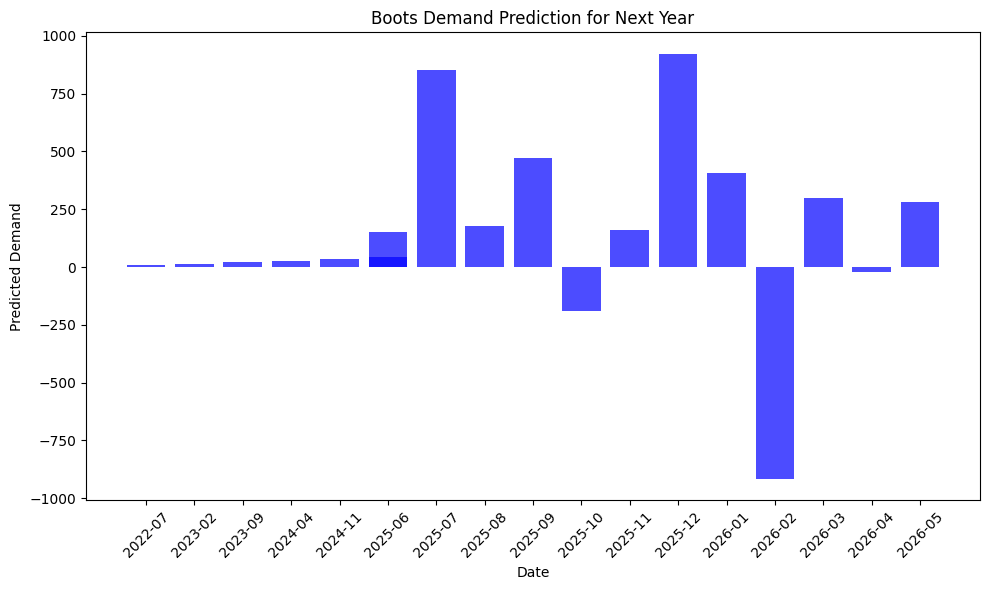

In [13]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load your actual data
df = pd.read_excel('Predictive_Analysis.xlsx')

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Function to run Prophet for each product type
def predict_product_demand(df, product):
    # Prepare the data for the specific product
    df_product = df[df['Type'] == product][['Date', 'ID']].rename(columns={'Date': 'ds', 'ID': 'y'}) # Filter for the specific product type and select the 'Date' and 'ID' columns

    # Initialize and fit the Prophet model
    model = Prophet()
    model.fit(df_product)

    # Create future dates for the next 12 months
    future = model.make_future_dataframe(periods=12, freq='M')

    # Predict future values
    forecast = model.predict(future)

    # Plotting predicted values using a bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(forecast['ds'].dt.strftime('%Y-%m'), forecast['yhat'], color='blue', alpha=0.7)
    plt.title(f"{product} Demand Prediction for Next Year")
    plt.xlabel("Date")
    plt.ylabel("Predicted Demand")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# List of all product types in the dataset
products = ['Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots']

# Loop through all product types and predict future demand
for product in products:
    predict_product_demand(df, product)